In [322]:
import torch
import numpy as np
from torch import nn
import matplotlib.pyplot as plt

torch.__version__

'2.10.0'

## Data preparing and loading

Data can be almost anything... in machine learning

* Excel speadsheet
* Images of any kind
* Videos
* Audio like songs
* DNA
* text

Machine learning is agame of two parts:
1. Get data into a numerical representation
2. Build a model to learn patterns in that representation.

To showcase this, let's create some *Known* data using the linear regression formula.

we'll use a linear regression formula to make a straight line with known parameters.

In [323]:
#Create known parameters
weight = 0.7
bias = 0.3

# create
start = 0
end = 1
step = 0.02
X = torch.arange(start,end,step).unsqueeze(dim = 1)
y = weight * X + bias 

X[:10],y[:10]


(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [324]:
len(X),len(y)

(50, 50)


### Splitting data in training and test sets(one of the most important concept in machine learning in gernal)


In [325]:
# create a train/test split
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:],y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

In [326]:
def plot_predictions(train_data = X_train,train_labels = y_train,
                    test_data = X_test,test_labels=y_test,predictions = None):

    """
    Plots training data,test data and compares predictions.
    """

    plt.figure(figsize = (10,7))

    # plot trainig data in blue
    plt.scatter(train_data,train_labels,c="b",s=4,label="Training data")

    #plot test data in green
    plt.scatter(test_data,test_labels,c="g",s=4,label = "Testing data")

    #Are there predictions?
    if predictions is not None:
        plt.scatter(test_data,predictions,c="r",s=4,label = "Prediction")

    #Show the legends
    plt.legend(prop = {"size" : 14});


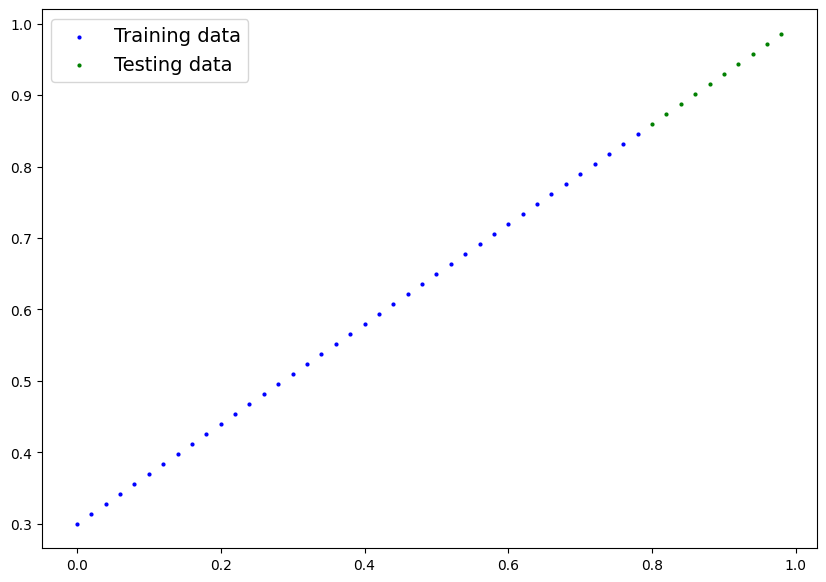

In [327]:
plot_predictions();

## 2. Build model
Our first pytorch model

In [328]:
# create a linear regression model class
class LinearRegressionModel(nn.Module): # almost everything in pytroch inherhits from nn.module
    def __init__(self):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(1,requires_grad = True,dtype=torch.float))
        self.bias = nn.Parameter(torch.randn(1,requires_grad = True,dtype = torch.float))

        # forward method to define the computation in the model
    def forward(self,x: torch.Tensor) -> torch.Tensor:
        return self.weight * x + self.bias



### checking the content of your pytroch model

In [329]:
# create a random seed
torch.manual_seed(42)

# create a subclass of the model
model_0 = LinearRegressionModel()

list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [330]:
# Listed named parameters
model_0.state_dict()

OrderedDict([('weight', tensor([0.3367])), ('bias', tensor([0.1288]))])

### Making prediction using torch.inference_mode()

In [331]:
# Make prediction with model
with torch.inference_mode():
    y_preds = model_0(X_test)

y_preds


tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

In [332]:
y_test

tensor([[0.8600],
        [0.8740],
        [0.8880],
        [0.9020],
        [0.9160],
        [0.9300],
        [0.9440],
        [0.9580],
        [0.9720],
        [0.9860]])

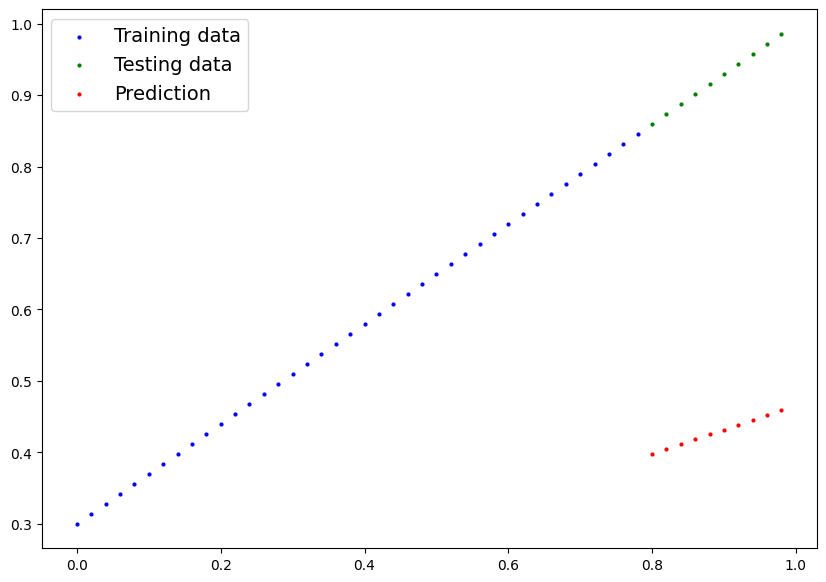

In [333]:
plot_predictions(predictions = y_preds)

In [334]:
# setup loss fuction 
loss_fn = nn.L1Loss()

# setup an optimizer
optimizer = torch.optim.SGD(params = model_0.parameters(),lr = 0.01)

### Building training loop in pytroch

In [335]:
# An epoach is one loop through the data.. (this is a hyperparameter)
epochs = 201

epoch_count = []
loss_values = []
test_loss_values = []

#0. loop through the data
for epoch in range(epochs):
    #setup the model to training mode
    model_0.train() # train mode in pytroch set all parameter that require graident to require gradients

    #1. forward pass
    y_pred = model_0(X_train)

    # 2 calucate the loss
    loss = loss_fn(y_pred , y_train)
    #print(f"loss: {loss}")

    #3. optimizer zero grad
    optimizer.zero_grad()

    #4 Perform backpropagation
    loss.backward()

    #5. step the optimiozer (perform descent )
    optimizer.step()    

    # Testing
    model_0.eval() # turns off gradient tracking
    with torch.inference_mode():
        # 1. do the forward pass
        test_pred = model_0(X_test)

        #2. calucate the loss
        test_loss = loss_fn(test_pred,y_test)
        
        if epoch %10 == 0:
            epoch_count.append(epoch)
            loss_values.append(loss)
            test_loss_values.append(test_loss)
            print(f"Epoch: {epoch} | Loss: {loss} | Test Loss: {test_loss}")

            print(model_0.state_dict())

        




Epoch: 0 | Loss: 0.31288135051727295 | Test Loss: 0.48106518387794495
OrderedDict({'weight': tensor([0.3406]), 'bias': tensor([0.1388])})
Epoch: 10 | Loss: 0.1976713389158249 | Test Loss: 0.3463551998138428
OrderedDict({'weight': tensor([0.3796]), 'bias': tensor([0.2388])})
Epoch: 20 | Loss: 0.08908725529909134 | Test Loss: 0.2172965705394745
OrderedDict({'weight': tensor([0.4184]), 'bias': tensor([0.3333])})
Epoch: 30 | Loss: 0.053148530423641205 | Test Loss: 0.14464019238948822
OrderedDict({'weight': tensor([0.4512]), 'bias': tensor([0.3768])})
Epoch: 40 | Loss: 0.04543796554207802 | Test Loss: 0.11360953748226166
OrderedDict({'weight': tensor([0.4748]), 'bias': tensor([0.3868])})
Epoch: 50 | Loss: 0.04167863354086876 | Test Loss: 0.09919948130846024
OrderedDict({'weight': tensor([0.4938]), 'bias': tensor([0.3843])})
Epoch: 60 | Loss: 0.03818932920694351 | Test Loss: 0.08886633813381195
OrderedDict({'weight': tensor([0.5116]), 'bias': tensor([0.3788])})
Epoch: 70 | Loss: 0.0347608998

In [336]:

np.array(torch.tensor(loss_values).numpy())

array([0.31288135, 0.19767134, 0.08908726, 0.05314853, 0.04543797,
       0.04167863, 0.03818933, 0.0347609 , 0.03132383, 0.0278874 ,
       0.02445896, 0.02102021, 0.01758547, 0.01415539, 0.01071659,
       0.00728353, 0.00385178, 0.00893248, 0.00893248, 0.00893248,
       0.00893248], dtype=float32)

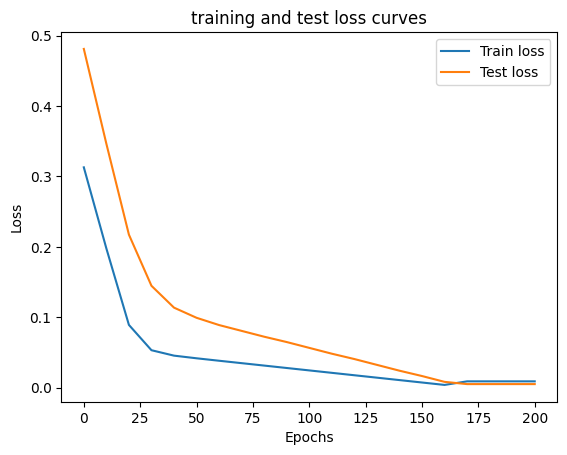

In [337]:
plt.plot(epoch_count,np.array(torch.tensor(loss_values).numpy()),label = "Train loss")
plt.plot(epoch_count,test_loss_values,label="Test loss")
plt.title("training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()
plt.show()

In [338]:
model_0.state_dict()

OrderedDict([('weight', tensor([0.6951])), ('bias', tensor([0.2993]))])

In [339]:
with torch.inference_mode():
    y_preds_new = model_0(X_test)

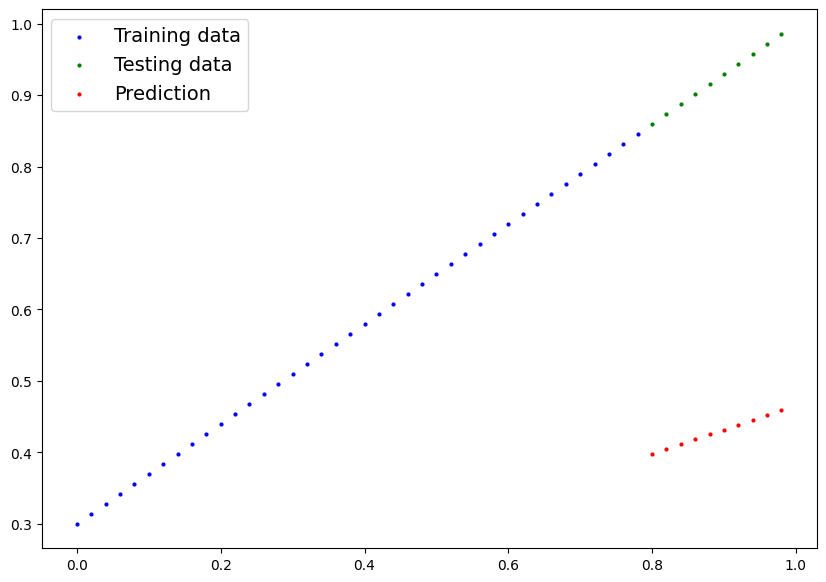

In [340]:
plot_predictions(predictions = y_preds)

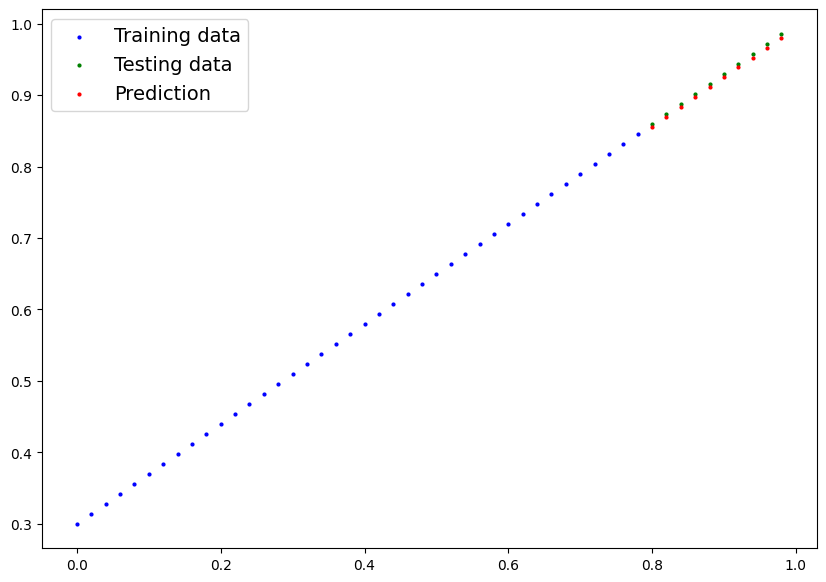

In [341]:
plot_predictions(predictions = y_preds_new)


## Saving a model in Pytroch

In [342]:
# save our pttroch model
from pathlib import Path

# create model directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents = True,exist_ok = True)

#2. Create model save path
MODEL_NAME = "01_pytroch_workflow_model_0.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

#3. save the model state_dict
print(f"Saving model to: {MODEL_SAVE_PATH}")

torch.save(obj=model_0.state_dict(),f = MODEL_SAVE_PATH)


Saving model to: models/01_pytroch_workflow_model_0.pth


In [343]:
!ls -l models

total 8
-rw-r--r--@ 1 niteshyadav  staff  2117 Jun  6 22:15 01_pytroch_workflow_model_0.pth


## Loading our pytorch model



In [346]:
# to load in a saved state_dict we have to instantiate a new instance of our model class
loaded_model_0 = LinearRegressionModel()

loaded_model_0.load_state_dict(torch.load(f = MODEL_SAVE_PATH))

<All keys matched successfully>

In [347]:
loaded_model_0.state_dict()

OrderedDict([('weight', tensor([0.6951])), ('bias', tensor([0.2993]))])

In [349]:
#Make some prediction with our loaded model
loaded_model_0.eval()
with torch.inference_mode():
    loaded_model_preds = loaded_model_0(X_test)

loaded_model_preds

tensor([[0.8554],
        [0.8693],
        [0.8832],
        [0.8971],
        [0.9110],
        [0.9249],
        [0.9388],
        [0.9527],
        [0.9666],
        [0.9805]])

In [350]:
model_0.eval()
with torch.inference_mode():
    y_preds = model_0(X_test)

y_preds

tensor([[0.8554],
        [0.8693],
        [0.8832],
        [0.8971],
        [0.9110],
        [0.9249],
        [0.9388],
        [0.9527],
        [0.9666],
        [0.9805]])

In [351]:
y_preds == loaded_model_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])